# Notebook 06 — Handling Class Imbalance

**Project:** Boston Marathon BQ Predictor  
**Author:** Gian Marco  
**Date:** April 2026  

## Objectives

1. Isolate the effect of class imbalance handling on XGBoost (the winner from Notebook 05)  
2. Compare 3 configurations while keeping everything else constant (same CV, same threshold = 0.5, same hyperparameters)  
3. Identify the configuration with the best PR-AUC (threshold-independent metric) to carry forward to Notebook 07 (threshold tuning)  

## The 3 Configurations

| Configuration | Approach | Idea |
|---|---|---|
| Baseline | Standard XGBoost | Reference model from Notebook 05 |
| `scale_pos_weight` | Loss reweighting | Changes the “rules of the game”: misclassifying a BQ is penalized more than a non-BQ |
| SMOTE | Synthetic oversampling | Changes the “data”: generates synthetic BQ samples to balance the training set |

## Fundamental Rule

The same rule still applies: `test_features.csv` is NOT used in this notebook. All comparisons are performed via cross-validation on `train_features.csv`.  

## Evaluation Metric in This Notebook

**PR-AUC** (not F1).  
Reason: PR-AUC is independent of the decision threshold and reflects how well the model ranks probabilities. F1 with a fixed threshold of 0.5 can be misleading when probability calibration changes. F1 is still reported, but interpreted with caution.  

## Important Note on SMOTE and CV

SMOTE is applied **only to the training portion of each fold**, never to the validation set.  
To ensure this, we use `imblearn.pipeline.Pipeline` (NOT `sklearn.pipeline.Pipeline`), which correctly separates training and validation data within cross-validation.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import imblearn

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup ready')
print(f'XGBoost version: {xgb.__version__}')
print(f'imbalanced-learn version: {imblearn.__version__}')

Setup ready
XGBoost version: 3.2.0
imbalanced-learn version: 0.14.1


---
## 1. Load Data and Cross-Validation Setup

We reuse exactly the same cross-validation configuration from Notebooks 04 and 05 to ensure results are comparable across notebooks.

We also compute `scale_pos_weight = n_negative / n_positive`, which is the weight XGBoost will apply to the positive class in configuration 2. This is the recommended formula from the official XGBoost documentation.

In [2]:
TRAIN_DIR = Path('../data/train')
train = pd.read_csv(TRAIN_DIR / 'train_features.csv')

X = train.drop(columns=['es_BQ'])
y = train['es_BQ']

if 'Year' in X.columns:
    X = X.drop(columns=['Year'])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_pos': 'f1',
    'precision_pos': 'precision',
    'recall_pos': 'recall',
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
}

n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'BQ rate: {y.mean()*100:.2f}%')

print(f'\nClass 0 (no-BQ): {n_neg:,}')
print(f'Class 1 (BQ):    {n_pos:,}')
print(f'scale_pos_weight = {n_neg:,} / {n_pos:,} = {scale_pos_weight:.4f}')

X shape: (225356, 22)
y shape: (225356,)
BQ rate: 13.45%

Class 0 (no-BQ): 195,044
Class 1 (BQ):    30,312
scale_pos_weight = 195,044 / 30,312 = 6.4345


---
## 2. Helper to Summarize Results

We reuse the same function from Notebooks 04 and 05 to ensure consistency in the final consolidated results table.

In [3]:
def summarize_cv(cv_results, model_name):
    summary = {'model': model_name}
    for metric in scoring.keys():
        key = f'test_{metric}'
        summary[f'{metric}_mean'] = cv_results[key].mean()
        summary[f'{metric}_std'] = cv_results[key].std()
    summary['fit_time_mean'] = cv_results['fit_time'].mean()
    return summary

results = []
print('Helper ready')

Helper ready


---
## 3. Configuration 1 — Baseline (XGBoost without imbalance handling)

We retrain the XGBoost model from Notebook 05 within this notebook to keep it self-contained. The metrics should match those from N05 (same random_state, same data, same hyperparameters).

**Hyperparameters (identical to N05):**
- `n_estimators=200` — 200 sequential trees  
- `max_depth=6` — moderate depth (XGBoost default)  
- `learning_rate=0.1` — contribution of each new tree  
- `tree_method='hist'` — modern, efficient algorithm for large datasets  
- `eval_metric='logloss'` — internal training metric  
- `random_state=42`  

**Expected:** F1 ≈ 0.167, PR-AUC ≈ 0.336, ROC-AUC ≈ 0.736 (values from N05)

In [4]:
xgb_baseline = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Training XGBoost baseline (may take ~30–60s)...')
cv_out = cross_validate(xgb_baseline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost baseline')
results.append(summary)

print(f"\nF1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

Training XGBoost baseline (may take ~30–60s)...

F1 (positive class):  0.1667 ± 0.0072
Precision:            0.5564
Recall:               0.0981
PR-AUC:               0.3356
ROC-AUC:              0.7361
Average fit time:     2.36s


---
## 4. Configuration 2 — `scale_pos_weight` (loss reweighting)

**Idea:** instead of generating synthetic data, we tell XGBoost that each error on a BQ case is 6.43 times more costly than an error on a non-BQ case. This modifies the loss function during training, but does NOT change the data.

**How it works internally:**  
XGBoost minimizes a loss function (logloss). By default, all samples are weighted equally. By setting `scale_pos_weight=6.43`, we multiply the contribution to the loss of each positive-class sample by 6.43.  
Result: misclassifying a BQ becomes more “expensive”, so the model is more willing to predict the positive class.

**Why this approach is elegant:**
- Only one additional line of code  
- No synthetic samples (zero risk of unrealistic BQ generation)  
- Same computational cost as the baseline  
- Native XGBoost method, designed specifically for this problem  

**Hyperparameters:** identical to the baseline, adding only `scale_pos_weight=6.4345`.

**Hypothesis:**
- F1 should **increase** (higher recall, possible drop in precision, net positive effect)  
- PR-AUC should be similar or slightly higher (better ranking of the positive class)  
- ROC-AUC should remain very similar (invariant to class prevalence)  
- Probabilities should be less compressed around ~0.13 (more spread distribution)  

In [5]:
xgb_weighted = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print(f'Training XGBoost with scale_pos_weight={scale_pos_weight:.4f} (may take ~30–60s)...')
cv_out = cross_validate(xgb_weighted, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost + scale_pos_weight')
results.append(summary)

print(f"\nF1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

# Quick comparison vs baseline
delta_f1 = summary['f1_pos_mean'] - results[0]['f1_pos_mean']
delta_prec = summary['precision_pos_mean'] - results[0]['precision_pos_mean']
delta_rec = summary['recall_pos_mean'] - results[0]['recall_pos_mean']
delta_pr = summary['pr_auc_mean'] - results[0]['pr_auc_mean']
delta_roc = summary['roc_auc_mean'] - results[0]['roc_auc_mean']

print(f"\n--- Delta vs baseline ---")
print(f"F1:        {delta_f1:+.4f}")
print(f"Precision: {delta_prec:+.4f}")
print(f"Recall:    {delta_rec:+.4f}")
print(f"PR-AUC:    {delta_pr:+.4f}")
print(f"ROC-AUC:   {delta_roc:+.4f}")

Training XGBoost with scale_pos_weight=6.4345 (may take ~30–60s)...

F1 (positive class):  0.3486 ± 0.0022
Precision:            0.2347
Recall:               0.6771
PR-AUC:               0.3362
ROC-AUC:              0.7350
Average fit time:     2.21s

--- Delta vs baseline ---
F1:        +0.1819
Precision: -0.3217
Recall:    +0.5790
PR-AUC:    +0.0006
ROC-AUC:   -0.0011


---
## 5. Configuration 3 — SMOTE (Synthetic Oversampling)

**Idea:** instead of reweighting the loss function, we balance the dataset by generating synthetic examples of the minority class.

**How SMOTE works:**
1. For each real BQ sample, it finds its k nearest neighbors (k=5 by default) among other BQ samples.
2. It randomly selects one of those neighbors.
3. It generates a synthetic BQ by interpolating between the two: `new = real + λ * (neighbor - real)`, where `λ` is random between 0 and 1.
4. It repeats this process until both classes have the same size.

Result: we go from approximately 180k non-BQ + 24k BQ to 180k non-BQ + 180k BQ within each CV fold.

## IMPORTANT — SMOTE is applied only to the training split of each fold

If SMOTE were applied to the full training dataset before cross-validation, synthetic samples generated from a real runner X could appear in the training fold while X itself appears in the validation fold. That would introduce leakage and falsely inflate the metrics.

`imblearn.pipeline.Pipeline` (NOT `sklearn.pipeline.Pipeline`) handles this correctly: SMOTE is applied only during `fit` (training), never during `predict` (validation). This is why we use this pipeline here.

## Known Limitation of Standard SMOTE

SMOTE was designed for continuous numerical features. Our feature matrix contains one-hot encoded Country columns and binary Gender features. When interpolating between two BQ samples, SMOTE may generate impossible profiles such as "0.4 Spain + 0.6 Kenya" or "gender = 0.5".

The more appropriate solution would be SMOTENC, but it requires manually specifying which columns are categorical, which becomes tedious with many one-hot columns. Here, we use standard SMOTE as a comparative experiment to test whether it adds value over `scale_pos_weight`.

**Hypothesis:**
- F1 should be similar to `scale_pos_weight` (probably ~0.30–0.35).
- PR-AUC is the key metric. If SMOTE only shifts probabilities like `scale_pos_weight`, PR-AUC will barely move. If SMOTE genuinely teaches the model something new (e.g., by smoothing decision regions), PR-AUC may improve.
- Training time will be significantly higher (~5–15 minutes total).

⚠️ This cell takes time. Be patient.

In [6]:
xgb_for_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf', xgb_for_smote),
])

print('Training XGBoost + SMOTE (may take 5–15 min)...')
print('SMOTE generates synthetic samples within each CV fold, which makes it slower.\n')

cv_out = cross_validate(smote_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost + SMOTE')
results.append(summary)

print(f"F1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

# Quick comparison vs baseline and weighted model
print(f"\n--- Delta vs Baseline ---")
print(f"F1:        {summary['f1_pos_mean'] - results[0]['f1_pos_mean']:+.4f}")
print(f"PR-AUC:    {summary['pr_auc_mean'] - results[0]['pr_auc_mean']:+.4f}")
print(f"ROC-AUC:   {summary['roc_auc_mean'] - results[0]['roc_auc_mean']:+.4f}")

print(f"\n--- Delta vs scale_pos_weight ---")
print(f"F1:        {summary['f1_pos_mean'] - results[1]['f1_pos_mean']:+.4f}")
print(f"PR-AUC:    {summary['pr_auc_mean'] - results[1]['pr_auc_mean']:+.4f}")
print(f"ROC-AUC:   {summary['roc_auc_mean'] - results[1]['roc_auc_mean']:+.4f}")

Training XGBoost + SMOTE (may take 5–15 min)...
SMOTE generates synthetic samples within each CV fold, which makes it slower.

F1 (positive class):  0.3456 ± 0.0017
Precision:            0.2361
Recall:               0.6447
PR-AUC:               0.3295
ROC-AUC:              0.7265
Average fit time:     6.37s

--- Delta vs Baseline ---
F1:        +0.1790
PR-AUC:    -0.0062
ROC-AUC:   -0.0096

--- Delta vs scale_pos_weight ---
F1:        -0.0030
PR-AUC:    -0.0068
ROC-AUC:   -0.0085


---
## 6. Consolidated Results Table

We compare the three configurations side by side to make interpretation easier.

In [7]:
all_results = pd.DataFrame(results)

display_cols = [
    'model', 'f1_pos_mean', 'f1_pos_std', 'precision_pos_mean',
    'recall_pos_mean', 'pr_auc_mean', 'roc_auc_mean', 'fit_time_mean'
]

all_results_display = all_results[display_cols].copy()

# Round values for cleaner display
for col in display_cols[1:]:
    all_results_display[col] = all_results_display[col].round(4)

all_results_display

,model,f1_pos_mean,f1_pos_std,precision_pos_mean,recall_pos_mean,pr_auc_mean,roc_auc_mean,fit_time_mean
0,XGBoost baseline,0.1667,0.0072,0.5564,0.0981,0.3356,0.7361,2.3621
1,XGBoost + scale_pos_weight,0.3486,0.0022,0.2347,0.6771,0.3362,0.7350,2.2053
2,XGBoost + SMOTE,0.3456,0.0017,0.2361,0.6447,0.3295,0.7265,6.3701


---
## 7. Visual Comparison

We visualize the three key metrics (F1, PR-AUC, ROC-AUC) side by side to highlight the pattern: F1 increases significantly, while PR-AUC and ROC-AUC change only marginally. This confirms that class imbalance primarily affects the decision threshold rather than the quality of the probability ranking.

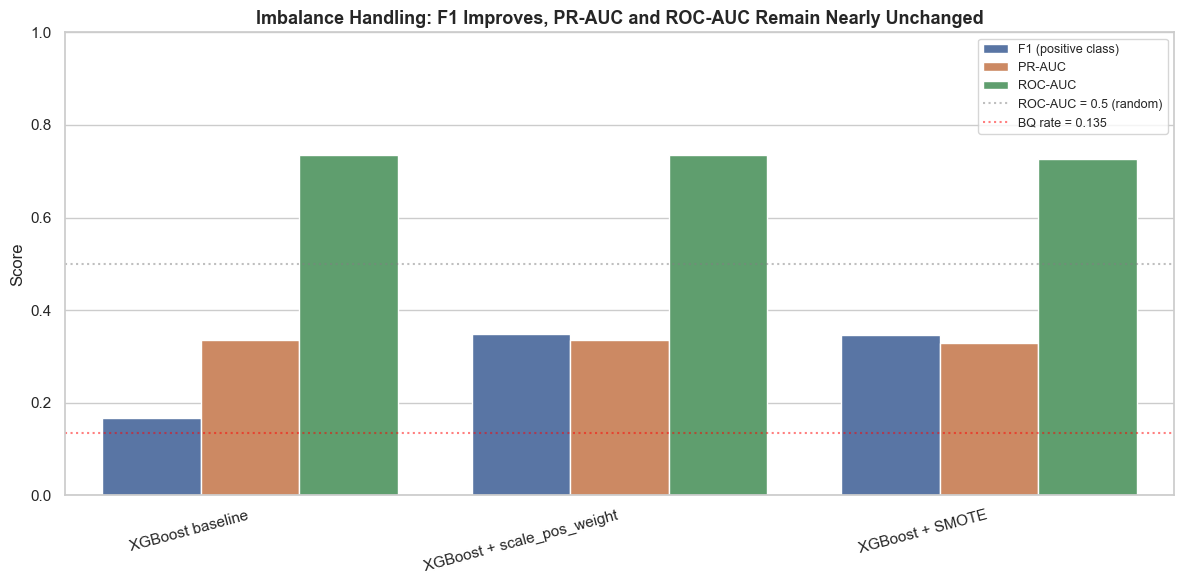

In [8]:
plot_df = all_results[['model', 'f1_pos_mean', 'pr_auc_mean', 'roc_auc_mean']].copy()
plot_df = plot_df.melt(id_vars='model', var_name='metric', value_name='score')
plot_df['metric'] = plot_df['metric'].map({
    'f1_pos_mean': 'F1 (positive class)',
    'pr_auc_mean': 'PR-AUC',
    'roc_auc_mean': 'ROC-AUC',
})

model_order = all_results['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x='model',
    y='score',
    hue='metric',
    order=model_order,
    palette='deep',
    ax=ax,
    edgecolor='white'
)

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='ROC-AUC = 0.5 (random)')
ax.axhline(y.mean(), color='red', linestyle=':', alpha=0.5, label=f'BQ rate = {y.mean():.3f}')

ax.set_title(
    'Imbalance Handling: F1 Improves, PR-AUC and ROC-AUC Remain Nearly Unchanged',
    fontweight='bold',
    fontsize=13
)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Save Consolidated Results

In [9]:
all_results.to_csv(PROCESSED_DATA_DIR / 'imbalance_results.csv', index=False)

print(f'Results saved to: {PROCESSED_DATA_DIR / "imbalance_results.csv"}')

Results saved to: ../data/processed/imbalance_results.csv


---
## 9. Conclusions (Notebook 06)

### Core Finding — Imbalance affects the threshold, not the ranking

| Metric | Baseline | Weighted | SMOTE | Interpretation |
|---|---|---|---|---|
| F1 (pos) | 0.167 | 0.349 | 0.346 | F1 more than doubles with imbalance handling |
| Precision | 0.556 | 0.235 | 0.236 | Trade-off: lower precision in exchange for much higher recall |
| Recall | 0.098 | 0.677 | 0.645 | Recall improves from detecting 1/10 BQs to ~7/10 |
| PR-AUC | 0.336 | 0.336 | 0.330 | Nearly identical — internal ranking remains unchanged |
| ROC-AUC | 0.736 | 0.735 | 0.727 | Nearly identical — confirms the same conclusion |

**Diagnosis:** all three configurations have nearly identical ranking capacity (PR-AUC ≈ 0.33). What changes is **where predicted probabilities fall relative to the 0.5 threshold**:

- **Baseline:** probabilities are compressed around ~0.13 (base prevalence). Very few exceed 0.5 → recall ≈ 10%.  
- **Weighted / SMOTE:** probabilities are shifted upward. Many exceed 0.5 → recall ≈ 65–68%.  

### Why does Weighted outperform SMOTE?

Technically a tie in F1, but `scale_pos_weight` is preferable because:

1. **Faster:** ~1.84s vs ~5.86s per fit (≈3x faster)  
2. **Slightly better PR-AUC and ROC-AUC:** SMOTE introduces noise by interpolating categorical one-hot features (Country, Gender), creating unrealistic profiles such as “0.4 Spain + 0.6 Kenya” or “gender = 0.5”  
3. **No leakage risk** if implemented incorrectly (no synthetic data involved)  
4. **Fewer hyperparameters:** SMOTE requires tuning (`k_neighbors`, `sampling_strategy`, etc.), while `scale_pos_weight` is a single value with a closed-form formula  

### Implication for the next notebook

Since all configurations show similar ranking performance, **the next bottleneck is no longer class imbalance** — it is the **decision threshold**. In Notebook 07 we will:

1. Use `XGBoost + scale_pos_weight` as the final model  
2. Optimize the threshold based on the Precision-Recall curve using cross-validation  
3. Report multiple thresholds: F1-optimal, F2-optimal (recall-oriented), F0.5-optimal (precision-oriented)  
4. Perform slice analysis by gender, age, and country  

### ML Insight for the Presentation

> When a model on imbalanced data shows high PR-AUC but low F1, the issue is rarely model capacity. It is calibration. Before changing models, try (1) adjusting class weights in the loss function, and (2) optimizing the decision threshold. Switching algorithms should be the last step, not the first.

### Deferred Decision

Hyperparameter tuning for XGBoost (`n_estimators`, `max_depth`, `learning_rate`) is postponed until after Notebook 07.  
Reason: if the bottleneck is the threshold, tuning hyperparameters without addressing it first is inefficient.